# Plots in the dissertation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from black_scholes.pinn.bs_pinn import BlackScholesPINN
from black_scholes.tree.tree import BinomialTree

from utility.plot import plot_price_heatmaps
from utility.continuation_prob import continuation_normal, compute_continuation_probs, estimate_continuation_value
from config.bs_1d import *

## Pricing

In [2]:
# Whole grid
num_S_whole = 100
num_T_whole = 100
Ss_whole = np.linspace(S_min, S_max, num_S_whole)
Ts_whole = np.linspace(0, T-1e-4, num_T_whole)

In [3]:
# Binomial tree
bt = BinomialTree(K, r, sigma, T, n_steps=100)

In [4]:
# Pinns
seeds = np.arange(40, 65)
pinns = []
for seed in seeds:
    pinn = BlackScholesPINN(model_config, seed=seed)
    pinn.set_params(K, r, sigma, T, S_min, S_max)
    pinn.load(f'../../models/bs_pinn_1d/standard/{seed}.pth')
    pinns.append(pinn)

### Price using our models

In [5]:
# Price using the PINNs
nn_prices_all = np.zeros((len(seeds), num_S_whole, num_T_whole))

for i, pinn in enumerate(pinns):
    nn_prices = np.zeros((num_T_whole, num_S_whole))
    for j, t_val in enumerate(Ts_whole):
        t_tensor = torch.full((num_S_whole,), t_val)
        nn_prices[j, :] = pinn.predict(t_tensor, Ss_whole).squeeze().numpy()
    nn_prices_all[i, :, :] = nn_prices

# Get price stats
nn_prices_mean = np.mean(nn_prices_all, axis=0)
nn_prices_std = np.std(nn_prices_all, axis=0, ddof=1)

#### Stats at $f(t=0, S=K)$

In [6]:
# Stats at f(t=0, S=K)

bt_atm_price = bt.predict(0, K)[0]
nn_atm_prices = np.array([pinn.predict(0, K).item() for pinn in pinns])
nn_atm_price = nn_atm_prices.mean()
nn_atm_price_std = nn_atm_prices.std(ddof=1)
nn_atm_confidence_interval = np.array([nn_atm_price - 1.96 * nn_atm_price_std / np.sqrt(len(pinns)), nn_atm_price + 1.96 * nn_atm_price_std / np.sqrt(len(pinns))])
nn_atm_price_range = np.array([nn_atm_prices.min(), nn_atm_prices.max()])

print("Binomial tree price:", bt_atm_price)
print("PINN price:", nn_atm_price)
print("Standard deviation:", nn_atm_price_std)
print("Price min/max:", nn_atm_price_range)
print("Standard error:", 1.96 * nn_atm_price_std / np.sqrt(len(pinns)))
print("95% confidence interval:", nn_atm_confidence_interval)
print("Relative error:", (bt_atm_price - nn_atm_price) / bt_atm_price)

Binomial tree price: 0.08325495336322662
PINN price: 0.0860252895951271
Standard deviation: 0.0006296080629941492
Price min/max: [0.08461264 0.08732761]
Standard error: 0.0002468063606937065
95% confidence interval: [0.08577848 0.0862721 ]
Relative error: -0.03327533221733963


In [7]:
# Price using the binomial tree
bt_prices = np.zeros((num_T_whole, num_S_whole))
for i, t_val in enumerate(Ts_whole):
    bt_prices[i, :] = bt.predict(t_val, Ss_whole)

## Comparing Binomial and PINN

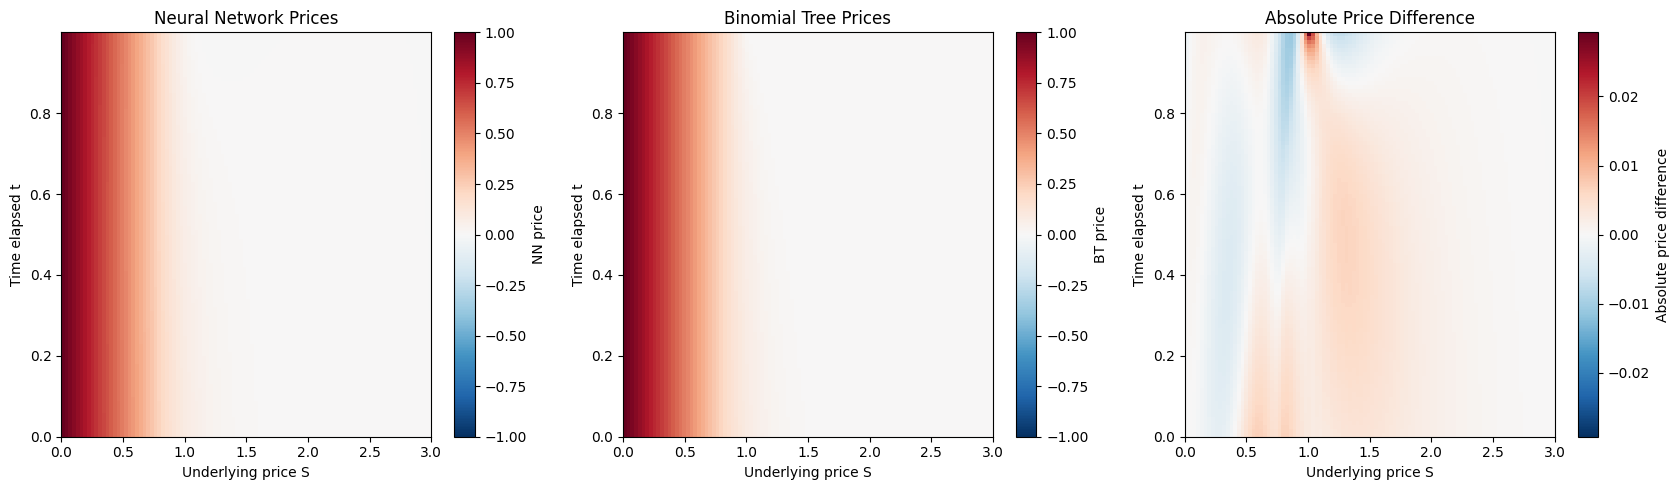

In [8]:
# Visualise the mean price surfaces
plot_price_heatmaps(
    prices1=nn_prices_mean, prices2=bt_prices,
    xlabel='Underlying price S', ylabel='Time elapsed t',
    title1='Neural Network Prices', title2='Binomial Tree Prices', title_diff='Absolute Price Difference',
    label1='NN price', label2='BT price', label_diff='Absolute price difference',
    extent=[Ss_whole[0], Ss_whole[-1], Ts_whole[0], Ts_whole[-1]],
    save_path='../../plots/black_scholes/bs_pinn_price_comparison.png'
)

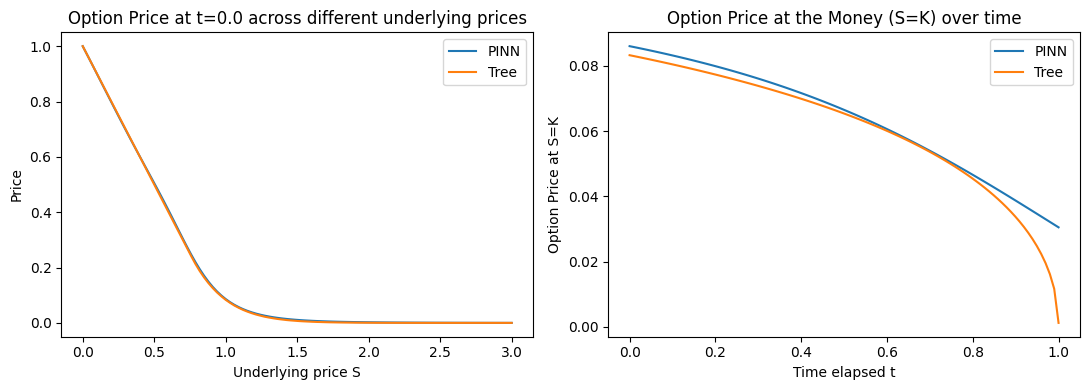

In [9]:
t_ind = 0
nn_prices_t0 = nn_prices_mean[t_ind, :]
bt_prices_t0 = bt_prices[t_ind, :]

# Error at the money
nn_prices_atm_all = np.zeros((len(pinns), num_T_whole))
S_try = K
for i, pinn in enumerate(pinns):
    nn_prices_atm_all[i] = np.array([pinn.predict(t, S_try).item() for t in Ts_whole])
nn_prices_atm = nn_prices_atm_all.mean(axis=0)
bt_prices_atm = np.array([bt.predict(t, S_try) for t in Ts_whole])


plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(Ss_whole, nn_prices_t0, label='PINN')
plt.plot(Ss_whole, bt_prices_t0, label='Tree')
plt.xlabel('Underlying price S')
plt.ylabel('Price')
plt.title(f'Option Price at t={Ts_whole[t_ind]} across different underlying prices')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Ts_whole, nn_prices_atm, label='PINN')
plt.plot(Ts_whole, bt_prices_atm, label='Tree')
plt.xlabel('Time elapsed t')
plt.ylabel('Option Price at S=K')
plt.title('Option Price at the Money (S=K) over time')
plt.legend()

plt.tight_layout()

plt.savefig('../../plots/black_scholes/bs_pinn_price_comparison_line.png')
plt.show()

## Continuation probabilities + Free boundary

In [10]:
# Free boundary grid
num_S_free = 200
num_T_free = 200
Ss_free = np.linspace(0.5, 1.2, num_S_free)
Ts_free = np.linspace(0, 1-1e-2, num_T_free)

intrinsics = np.tile(np.maximum(K - Ss_free, 0), (num_T_free, 1))

### Free boundary with binomial tree

In [11]:
bt_continuation_values = np.zeros((num_T_free, num_S_free))
for i, t_val in enumerate(Ts_free):
    bt_continuation_values[i, :] = bt.predict(t_val, Ss_free, continuation_value=True)
bt_continuation_probs = np.where(bt_continuation_values > intrinsics, 1.0, 0.0)


### Free boundary with PINN

#### Test for Gaussianity

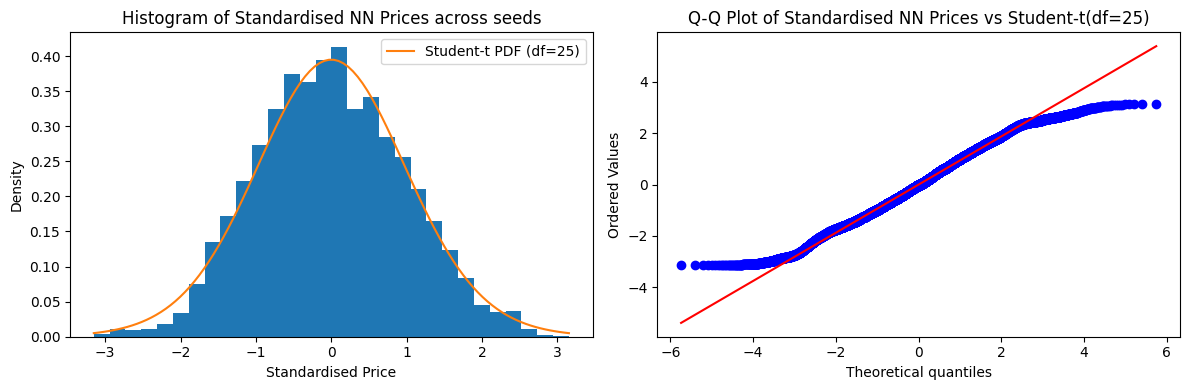

In [12]:
from scipy.stats import norm, t, probplot

nn_prices_standardised = (nn_prices_all - nn_prices_mean) / nn_prices_std

# plot standard normal and qq plot
x_min = np.min(nn_prices_standardised)
x_max = np.max(nn_prices_standardised)
x = np.linspace(x_min, x_max, 100)

ddof = len(seeds)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(nn_prices_standardised.flatten(), bins=30, density=True)
# plt.plot(x, norm.pdf(x), label='Standard Normal PDF')
plt.plot(x, t.pdf(x, df=ddof), label=f'Student-t PDF (df={ddof})')
plt.xlabel('Standardised Price')
plt.ylabel('Density')
plt.title('Histogram of Standardised NN Prices across seeds')
plt.legend()

## qq plot
plt.subplot(1, 2, 2)
probplot(nn_prices_standardised.flatten(), dist=t, sparams=(ddof,), plot=plt)
plt.title(f'Q-Q Plot of Standardised NN Prices vs Student-t(df={ddof})')

plt.tight_layout()

plt.savefig('../../plots/black_scholes/nn_price_distribution.png')
plt.show()

#### Continuation value with Monte Carlo

In [13]:
nn_cont_values_all = np.zeros((num_T_free, num_S_free, len(pinns)))
for i, t in enumerate(Ts_free):
    for j, S in enumerate(Ss_free):
        for k, pinn in enumerate(pinns):
            nn_cont_values_all[i, j, k] = estimate_continuation_value(pinns[k].model, t, S, r, sigma, n_paths=100, h=0.01, seed=42)

nn_cont_values = nn_cont_values_all.mean(axis=2)
nn_cont_values_std = nn_cont_values_all.std(axis=2, ddof=1)

#### Free boundary

/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:29: RuntimeWarning: divide by zero encountered in divide
  d = (continuation - intrinsics + shift) / intrinsics


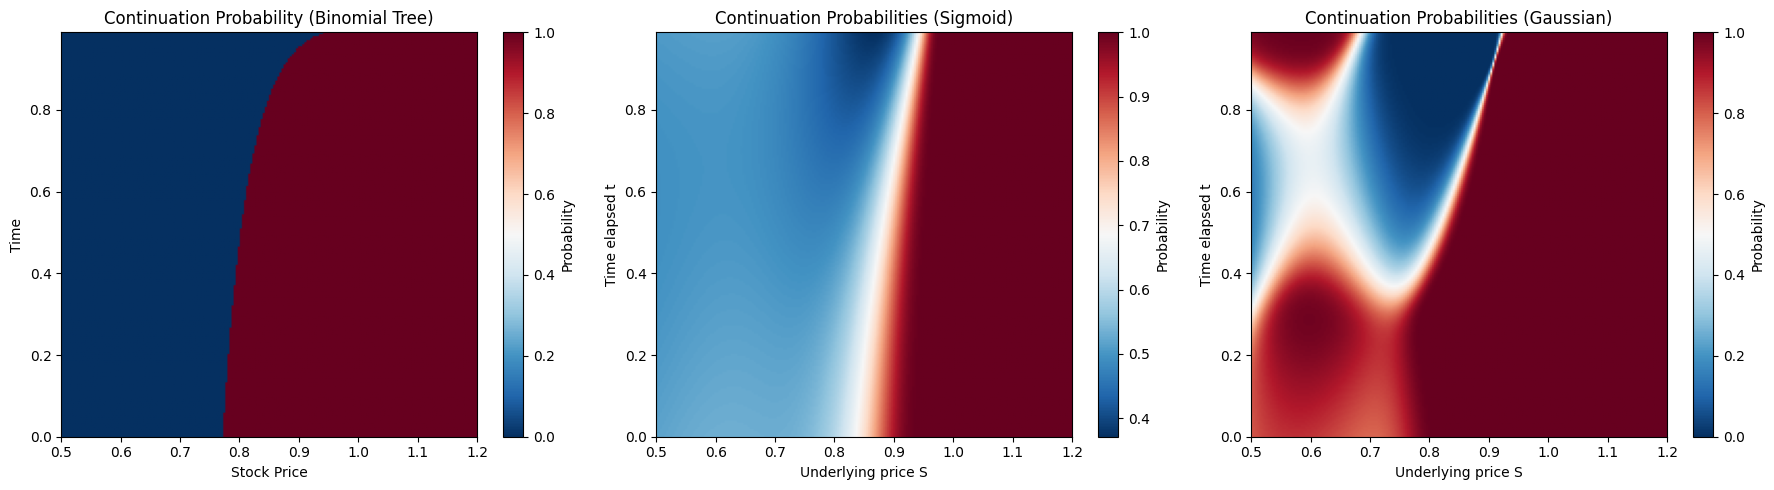

In [14]:
# Sigmoid
eps = 0.6
nn_continuation_probs_sigmoid = compute_continuation_probs(nn_cont_values, intrinsics, eps, 0.99, 0)

# Gaussian
nn_continuation_probs_gaussian = continuation_normal(nn_cont_values, nn_cont_values_std, intrinsics)


# plot continuation values
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(bt_continuation_probs, extent=[Ss_free[0], Ss_free[-1], Ts_free[0], Ts_free[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Probability')
plt.xlabel('Stock Price')
plt.ylabel('Time')
plt.title('Continuation Probability (Binomial Tree)')

plt.subplot(1, 3, 2)

plt.imshow(nn_continuation_probs_sigmoid, extent=[Ss_free[0], Ss_free[-1], Ts_free[0], Ts_free[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Probability')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Continuation Probabilities (Sigmoid)')

plt.subplot(1, 3, 3)
plt.imshow(nn_continuation_probs_gaussian, extent=[Ss_free[0], Ss_free[-1], Ts_free[0], Ts_free[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Probability')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Continuation Probabilities (Gaussian)')
plt.tight_layout()

plt.savefig('../../plots/black_scholes/bs_continuation_probs.png')
plt.show()